## 1. Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Gaya plot
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('Library berhasil di-import!')

Library berhasil di-import!


## 2. Load Dataset

In [6]:
df = pd.read_csv(r'C:\Users\Asus_TUF\pba2026-kelompok-15\data\datachtpolitik.csv')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')
df.head()

Jumlah baris: 1204, Jumlah kolom: 6


,tanggal_baca,id,clean_author,clean_text,score,sentiment
0,2026-02-01 00:37:00,UgwJBQoqBYOUx9eXiXl4AaABAg,@okkymahardika4502,Osang Asing Osang Asing. Lebih Baik Makan Osen...,-1,Negatif
1,2026-02-01 00:36:00,Ugx7cZ0WLmkm4MDSRL54AaABAg,@okkymahardika4502,Lupa Apa Pikun ?,-1,Negatif
2,2026-02-01 00:28:00,UgyuCla61YcmH2KIFmN4AaABAg,@okkymahardika4502,YO,0,Netral
3,2026-02-01 00:00:00,Ugw3wcI-_lbARyc6uyt4AaABAg,@gregtriplex5878,Tempo itu sejak sidney jones itu udah jelas bg...,-1,Negatif
4,2026-01-31 22:00:00,Ugzc9xNck1ZsmbC7l6h4AaABAg,@taufan322,Inilah yang terjadi kalau segala sesuatu disel...,0,Netral


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1204 entries, 0 to 1203
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   tanggal_baca  1204 non-null   str  
 1   id            1204 non-null   str  
 2   clean_author  1204 non-null   str  
 3   clean_text    1204 non-null   str  
 4   score         1204 non-null   int64
 5   sentiment     1204 non-null   str  
dtypes: int64(1), str(5)
memory usage: 275.8 KB


In [7]:
df.describe(include='all')

,tanggal_baca,id,clean_author,clean_text,score,sentiment
count,1204,1204,1204,1204,1204.000000,1204
unique,21,1204,961,1171,NaN,3
top,2026-01-25 07:00:00,UgwJBQoqBYOUx9eXiXl4AaABAg,@Noor.M-mg8mo,"Coba Donkk kalo bukan antek asing, mau donk ba...",NaN,Negatif
freq,664,1,76,9,NaN,761
mean,NaN,NaN,NaN,NaN,-1.841362,NaN
std,NaN,NaN,NaN,NaN,2.413026,NaN
min,NaN,NaN,NaN,NaN,-18.000000,NaN
25%,NaN,NaN,NaN,NaN,-3.000000,NaN
50%,NaN,NaN,NaN,NaN,-1.000000,NaN
75%,NaN,NaN,NaN,NaN,0.000000,NaN


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Label Sentimen

In [8]:
sentiment_counts = df['sentiment'].value_counts()
print('Distribusi sentimen:')
print(sentiment_counts)
print(f'\nProporsi (%):')
print((sentiment_counts / len(df) * 100).round(2))

Distribusi sentimen:
sentiment
Negatif    761
Netral     361
Positif     82
Name: count, dtype: int64

Proporsi (%):
sentiment
Negatif    63.21
Netral     29.98
Positif     6.81
Name: count, dtype: float64


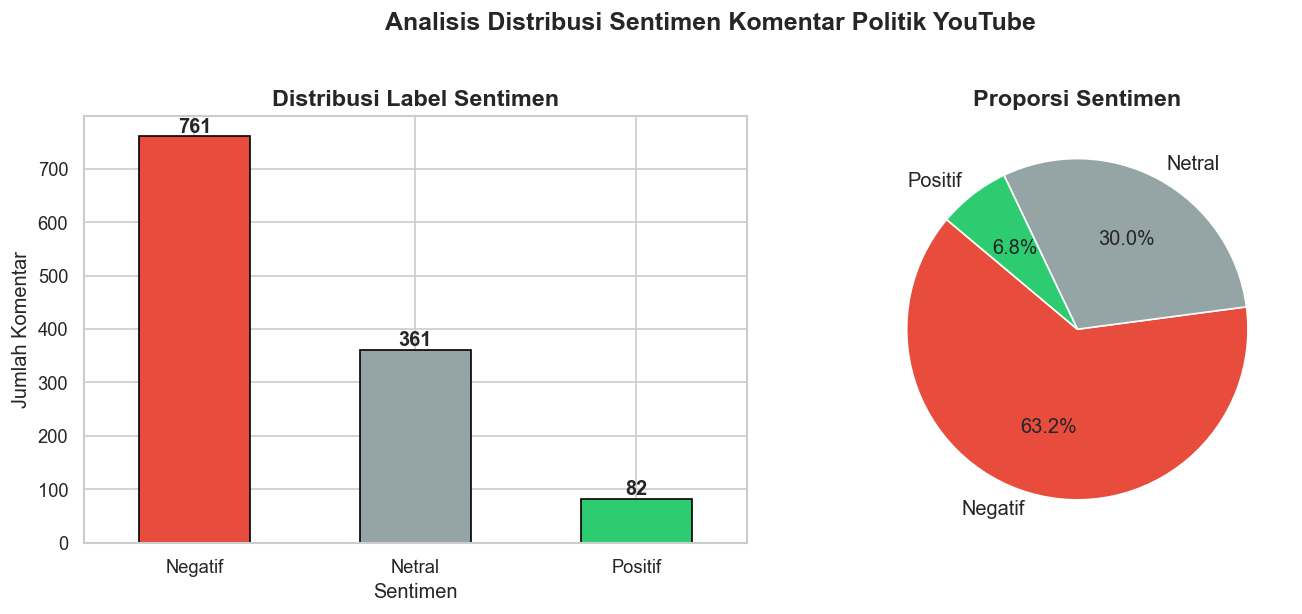

Dataset ini TIDAK seimbang (imbalanced). Negatif mendominasi.


In [10]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Komentar')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Sentimen', fontsize=14, fontweight='bold')

plt.suptitle('Analisis Distribusi Sentimen Komentar Politik YouTube', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/distribusi_sentimen.png', bbox_inches='tight')
plt.show()
print('Dataset ini TIDAK seimbang (imbalanced). Negatif mendominasi.')

### 3.2 Analisis Panjang Teks

In [13]:
df['text_length'] = df['clean_text'].str.len()
df['word_count'] = df['clean_text'].str.split().str.len()

print('Statistik panjang karakter per sentimen:')
print(df.groupby('sentiment')['text_length'].describe().round(2))
print()
print('Statistik jumlah kata per sentimen:')
print(df.groupby('sentiment')['word_count'].describe().round(2))

Statistik panjang karakter per sentimen:
           count    mean     std  min   25%   50%    75%     max
sentiment                                                       
Negatif    761.0  132.40  135.75  8.0  50.0  90.0  188.0  1239.0
Netral     345.0   75.19  104.16  3.0  28.0  49.0   88.0  1350.0
Positif     82.0  132.93  121.74  5.0  51.0  97.5  163.0   546.0

Statistik jumlah kata per sentimen:
           count   mean    std  min   25%   50%    75%    max
sentiment                                                    
Negatif    761.0  20.29  19.38  2.0  8.00  14.0  30.00  170.0
Netral     345.0  11.24  14.59  1.0  4.00   7.0  13.00  169.0
Positif     82.0  20.22  18.39  1.0  8.25  14.5  24.75   87.0


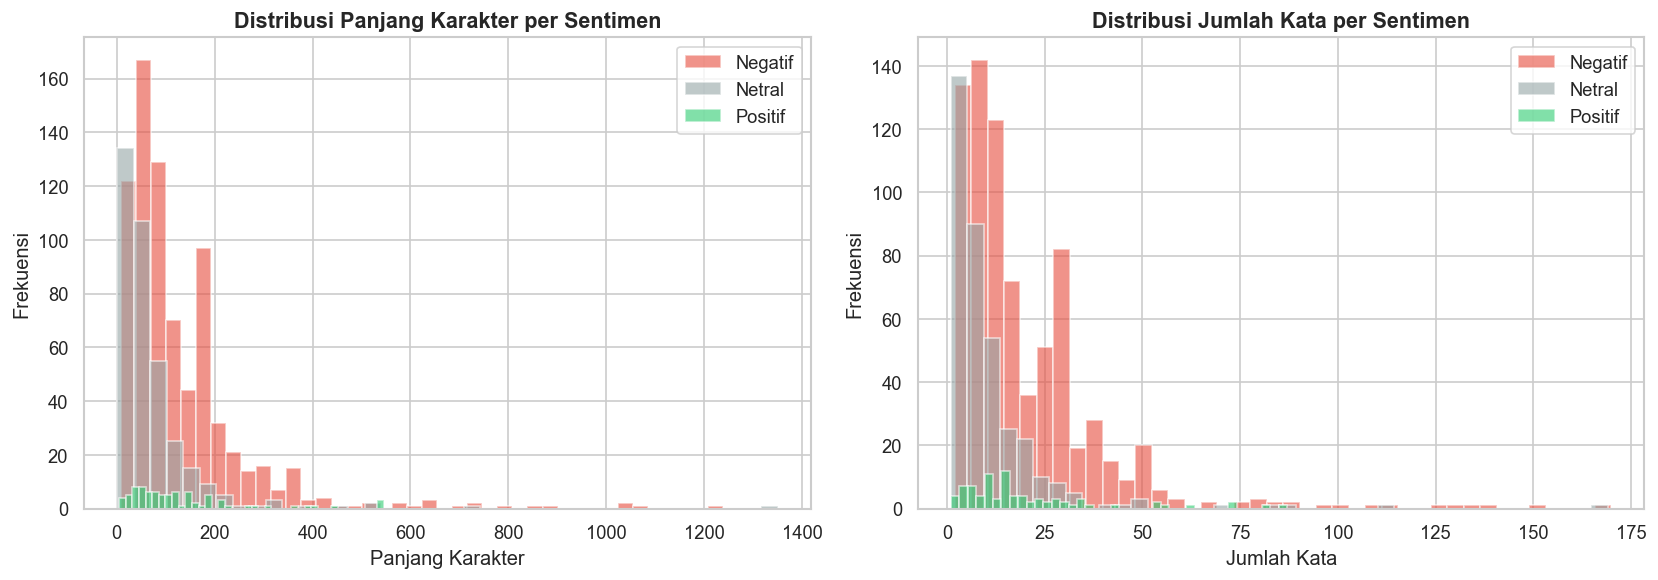

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['text_length', 'word_count'], ['Panjang Karakter', 'Jumlah Kata']):
    for sent, color in zip(['Negatif', 'Netral', 'Positif'], ['#e74c3c', '#95a5a6', '#2ecc71']):
        subset = df[df['sentiment'] == sent][col]
        ax.hist(subset, bins=40, alpha=0.6, label=sent, color=color, edgecolor='white')
    ax.set_title(f'Distribusi {title} per Sentimen', fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.savefig('../assets/distribusi_panjang_teks.png', bbox_inches='tight')
plt.show()

### 3.3 Distribusi Score

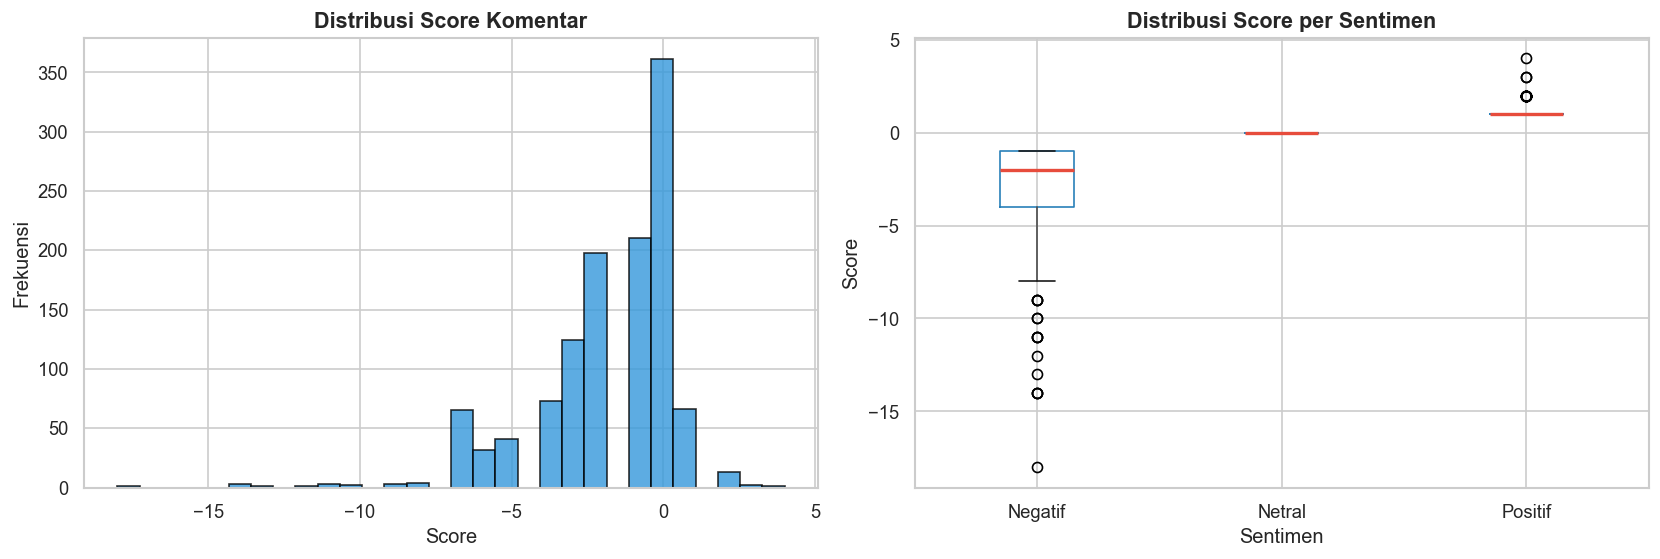

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram score
axes[0].hist(df['score'], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribusi Score Komentar', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frekuensi')

# Boxplot score per sentimen
df.boxplot(column='score', by='sentiment', ax=axes[1],
           boxprops=dict(color='#2980b9'),
           medianprops=dict(color='#e74c3c', linewidth=2))
axes[1].set_title('Distribusi Score per Sentimen', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../assets/distribusi_score.png', bbox_inches='tight')
plt.show()

### 3.4 Analisis Temporal (Tren Waktu)

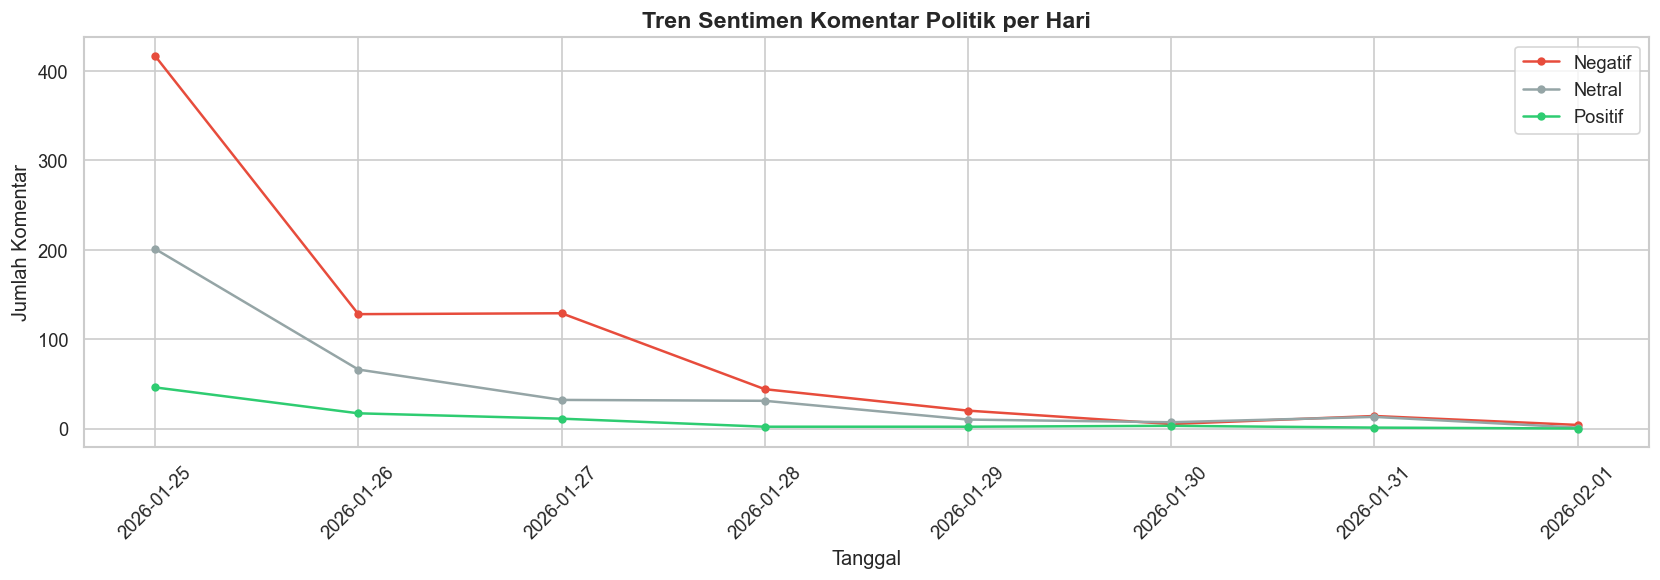

In [14]:
df['tanggal_baca'] = pd.to_datetime(df['tanggal_baca'])
df['tanggal'] = df['tanggal_baca'].dt.date

daily_sentiment = df.groupby(['tanggal', 'sentiment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
colors_map = {'Negatif': '#e74c3c', 'Netral': '#95a5a6', 'Positif': '#2ecc71'}
for col in daily_sentiment.columns:
    ax.plot(daily_sentiment.index, daily_sentiment[col], marker='o', markersize=4,
            label=col, color=colors_map.get(col, 'gray'))

ax.set_title('Tren Sentimen Komentar Politik per Hari', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Komentar')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/tren_temporal.png', bbox_inches='tight')
plt.show()

### 3.5 Top 20 Kata Paling Sering

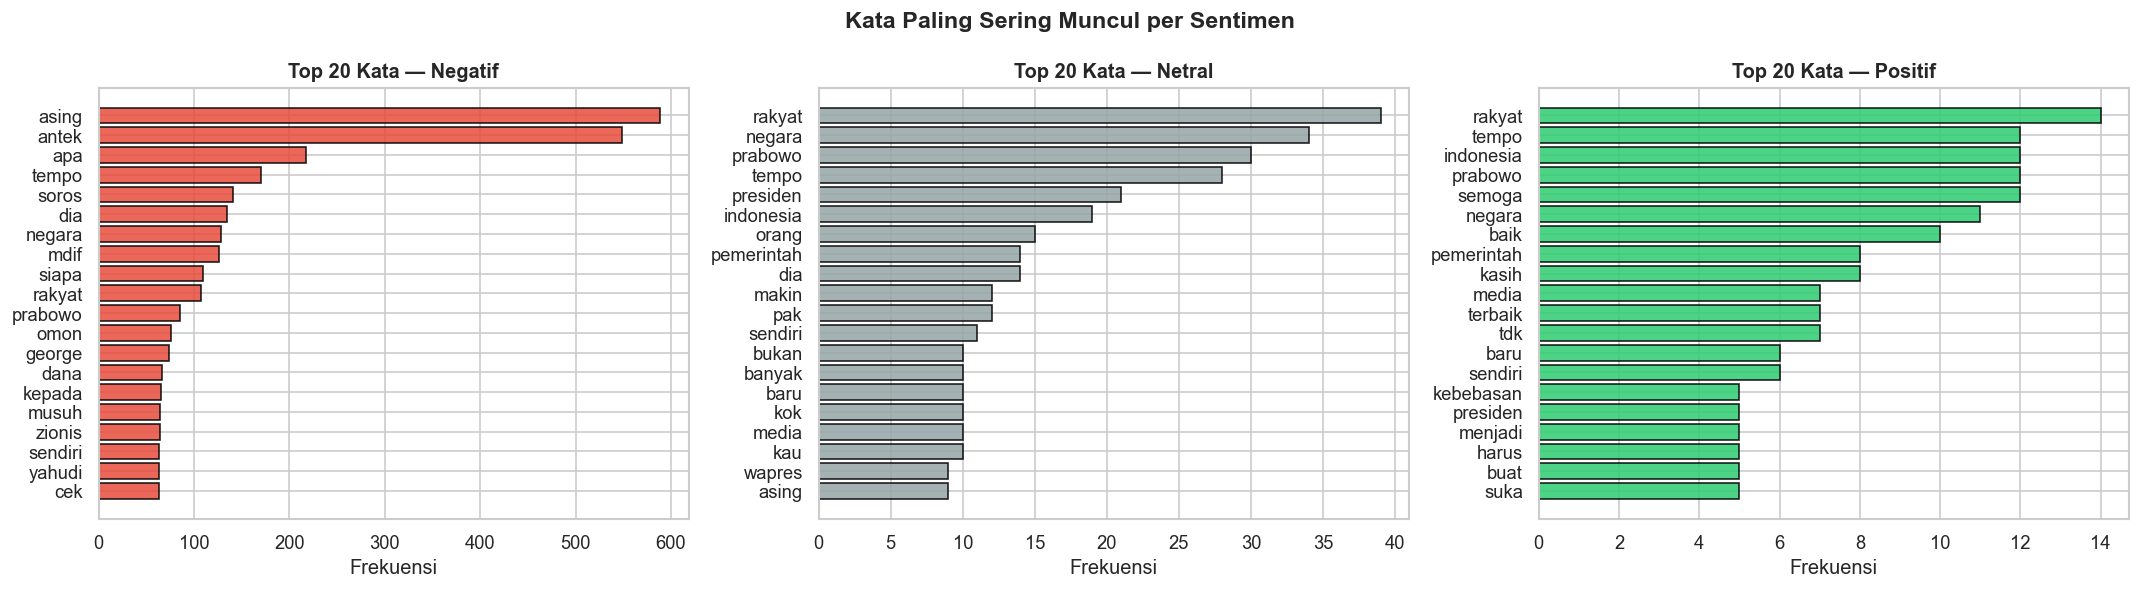

In [15]:
# Stopwords bahasa Indonesia sederhana
stopwords_id = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk', 'adalah',
    'pada', 'tidak', 'juga', 'sudah', 'saya', 'anda', 'kita', 'mereka', 'kami',
    'ada', 'akan', 'bisa', 'dalam', 'oleh', 'atau', 'tetapi', 'tapi', 'karena',
    'jika', 'kalau', 'ya', 'yg', 'nya', 'nya', 'bagi', 'aja', 'ga', 'gak', 'nggak',
    'dg', 'dgn', 'dr', 'yg', 'utk', 'spy', 'klo', 'gitu', 'udah', 'nih', 'nih',
    'lah', 'dong', 'sih', 'tuh', 'kan', 'deh', 'nya', 'lagi', 'jadi', 'lebih',
    'seperti', 'hanya', 'saja', 'mau', 'sama', 'kalian', 'semua'
])

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        if pd.notna(text):
            for w in str(text).lower().split():
                w = re.sub(r'[^a-zA-Z]', '', w)
                if len(w) > 2 and w not in stopwords_id:
                    words.append(w)
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sent, color in zip(axes, ['Negatif', 'Netral', 'Positif'], ['#e74c3c', '#95a5a6', '#2ecc71']):
    top_words = get_top_words(df[df['sentiment'] == sent]['clean_text'])
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 20 Kata — {sent}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.suptitle('Kata Paling Sering Muncul per Sentimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/top_words.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing

### 4.1 Cek Missing Values & Duplikat

In [17]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Missing Values ===
tanggal_baca    0
id              0
clean_author    0
clean_text      0
score           0
sentiment       0
text_length     0
word_count      0
tanggal         0
dtype: int64

=== Duplikat ===
Jumlah baris duplikat: 0


### 4.2 Pembersihan Teks

In [7]:
def preprocess_text(text):
    """Membersihkan teks: lowercase, hapus simbol, mention, URL."""
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)          # Hapus mention
    text = re.sub(r'http\S+|www\S+', '', text) # Hapus URL
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # Hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip()    # Normalisasi spasi
    return text

df['text_processed'] = df['clean_text'].apply(preprocess_text)

# Contoh
for _, row in df.head(3).iterrows():
    print(f'Original : {row["clean_text"]}')
    print(f'Processed: {row["text_processed"]}')
    print()

Original : Osang Asing Osang Asing. Lebih Baik Makan Oseng-Oseng Aja. Enak. 😁 Ha Ha Ha Ha Ha Ha
Processed: osang asing osang asing lebih baik makan oseng oseng aja enak ha ha ha ha ha ha

Original : Lupa Apa Pikun ?
Processed: lupa apa pikun

Original : YO
Processed: yo



### 4.3 Hapus Teks Kosong

In [8]:
before = len(df)
df = df[df['text_processed'].str.strip().str.len() > 2].copy()
after = len(df)
print(f'Baris sebelum: {before}, setelah hapus teks kosong: {after}, dihapus: {before - after}')

Baris sebelum: 1204, setelah hapus teks kosong: 1188, dihapus: 16


### 4.4 Encoding Label

In [9]:
label_map = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
df['label'] = df['sentiment'].map(label_map)

print('Mapping label:')
print(label_map)
print()
print(df[['sentiment', 'label']].value_counts())

Mapping label:
{'Negatif': 0, 'Netral': 1, 'Positif': 2}

sentiment  label
Negatif    0        761
Netral     1        345
Positif    2         82
Name: count, dtype: int64


### 4.5 Feature Engineering: TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import scipy.sparse as sp

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = vectorizer.fit_transform(df['text_processed'])
y = df['label']

print(f'Shape matriks TF-IDF: {X.shape}')
print(f'Jumlah fitur (vocab): {len(vectorizer.vocabulary_)}')

Shape matriks TF-IDF: (1188, 2963)
Jumlah fitur (vocab): 2963


### 4.6 Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Data training: {X_train.shape[0]} sampel')
print(f'Data testing : {X_test.shape[0]} sampel')

print(f'\nDistribusi label training:')
print(pd.Series(y_train).value_counts())
print(f'\nDistribusi label testing:')
print(pd.Series(y_test).value_counts())

Data training: 950 sampel
Data testing : 238 sampel

Distribusi label training:
label
0    608
1    276
2     66
Name: count, dtype: int64

Distribusi label testing:
label
0    153
1     69
2     16
Name: count, dtype: int64


### 4.7 Simpan Dataset yang Sudah Diproses

In [14]:
import os, joblib
os.makedirs('../data', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

# Simpan dataframe hasil preprocessing
df[['text_processed', 'sentiment', 'label', 'score', 'text_length', 'word_count']].to_csv(
    '../data/data_preprocessed.csv', index=False
)

# Simpan vectorizer untuk digunakan di notebook berikutnya
joblib.dump(vectorizer, '../data/tfidf_vectorizer.pkl')

print('Dataset preprocessed dan vectorizer berhasil disimpan!')
print('File:')
print('  - data/data_preprocessed.csv')
print('  - data/tfidf_vectorizer.pkl')

Dataset preprocessed dan vectorizer berhasil disimpan!
File:
  - data/data_preprocessed.csv
  - data/tfidf_vectorizer.pkl


## 5. Ringkasan EDA

| Aspek | Temuan |
|-------|--------|
| Jumlah data | 1.204 komentar |
| Distribusi kelas | Imbalanced: Negatif ~63%, Netral ~30%, Positif ~7% |
| Missing values | Tidak ada |
| Duplikat | Tidak ada |
| Panjang teks | Rata-rata komentar pendek (< 50 kata) |
| Fitur TF-IDF | 5.000 fitur, n-gram (1,2) |
| Target | Klasifikasi 3 kelas: Negatif (0), Netral (1), Positif (2) |

**Catatan penting:** Karena data sangat tidak seimbang (imbalanced), kita akan menggunakan `class_weight='balanced'` dan metrik evaluasi tambahan seperti F1-score macro saat modeling.